In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Metro_Interstate_Traffic_Volume.csv")

## Data Preprocessing

In [4]:
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [5]:
df["weather_main"].value_counts()

weather_main
Clouds          15164
Clear           13391
Mist             5950
Rain             5672
Snow             2876
Drizzle          1821
Haze             1360
Thunderstorm     1034
Fog               912
Smoke              20
Squall              4
Name: count, dtype: int64

In [6]:
df.isna().sum()

holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(17)

In [8]:
df.drop_duplicates(keep = "first",inplace = True)

In [9]:
df["holiday"] = df["holiday"].fillna("None")

In [10]:
df.dtypes

holiday                 object
temp                   float64
rain_1h                float64
snow_1h                float64
clouds_all               int64
weather_main            object
weather_description     object
date_time               object
traffic_volume           int64
dtype: object

In [11]:
num_cols = ["temp","rain_1h","snow_1h","clouds_all","traffic_volume"]
df[num_cols].corr()

,temp,rain_1h,snow_1h,clouds_all,traffic_volume
temp,1.000000,0.009070,-0.019756,-0.101968,0.130161
rain_1h,0.009070,1.000000,-0.000090,0.004818,0.004715
snow_1h,-0.019756,-0.000090,1.000000,0.027934,0.000736
clouds_all,-0.101968,0.004818,0.027934,1.000000,0.067138
traffic_volume,0.130161,0.004715,0.000736,0.067138,1.000000


<Axes: >

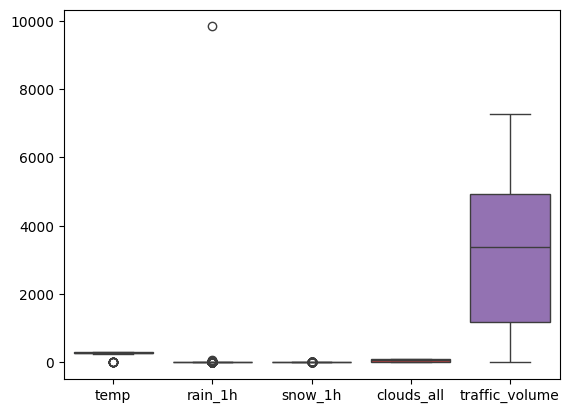

In [12]:
sns.boxplot(df)

In [13]:
num_cols

['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'traffic_volume']

In [14]:
num_cols = ["temp"]
from feature_engine.outliers import Winsorizer
winsor = Winsorizer(capping_method = "iqr",tail = 'both',fold = 1.5)
df[num_cols] = winsor.fit_transform(df[num_cols])

<Axes: >

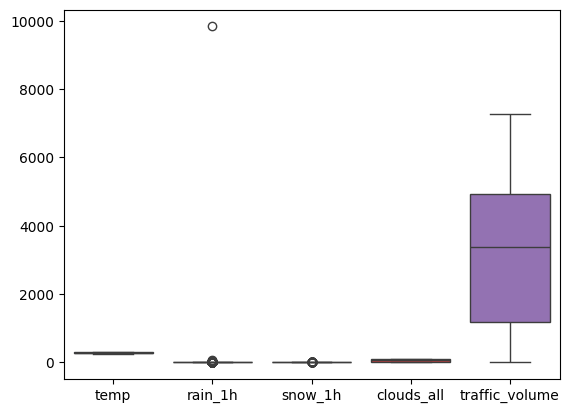

In [15]:
sns.boxplot(df)

In [16]:
df = df.drop(columns = ["weather_description"],axis = 1)

In [17]:
df.columns

Index(['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main',
       'date_time', 'traffic_volume'],
      dtype='object')

In [18]:
df["date_time"] = pd.to_datetime(df["date_time"])
df['hour'] = df['date_time'].dt.hour
df['day'] = df['date_time'].dt.day
df['month'] = df['date_time'].dt.month
df['dayofweek'] = df['date_time'].dt.dayofweek

In [19]:
df = df.drop(columns = ["date_time"],axis = 1)

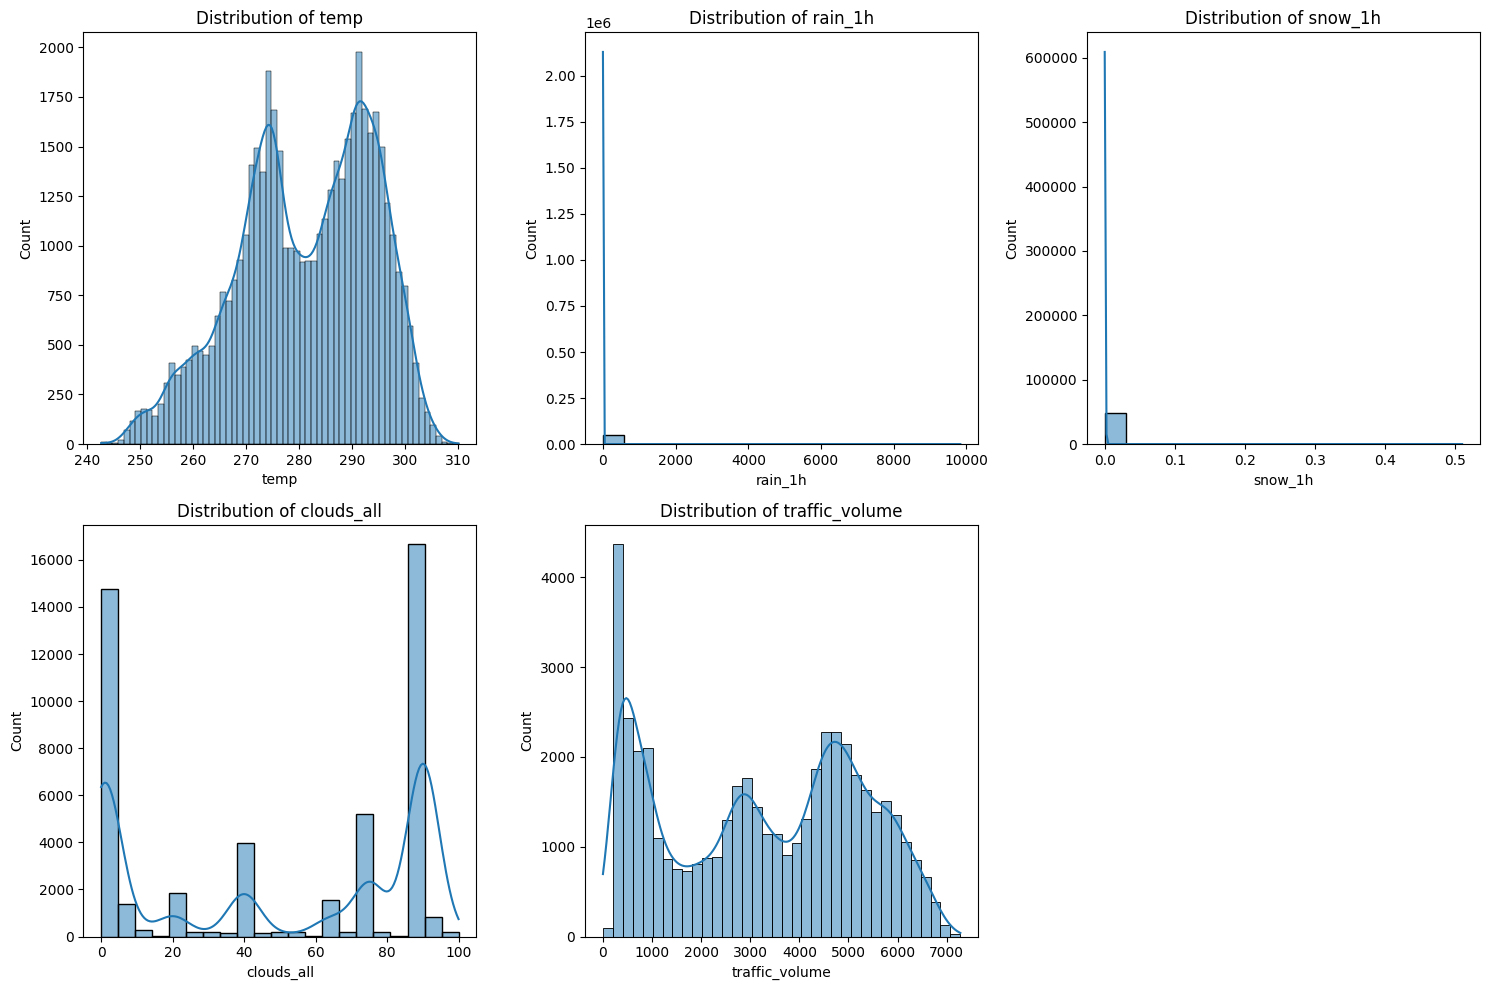

In [20]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Set subplot grid
n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

In [21]:
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,traffic_volume,hour,day,month,dayofweek
0,None,288.28,0.0,0.0,40,Clouds,5545,9,2,10,1
1,None,289.36,0.0,0.0,75,Clouds,4516,10,2,10,1
2,None,289.58,0.0,0.0,90,Clouds,4767,11,2,10,1
3,None,290.13,0.0,0.0,90,Clouds,5026,12,2,10,1
4,None,291.14,0.0,0.0,75,Clouds,4918,13,2,10,1


In [22]:
df.dtypes

holiday            object
temp              float64
rain_1h           float64
snow_1h           float64
clouds_all          int64
weather_main       object
traffic_volume      int64
hour                int32
day                 int32
month               int32
dayofweek           int32
dtype: object

In [23]:
df["is_holiday"] = df["holiday"].apply(lambda x: 0 if x == 'None' else 1)
df.drop(columns = ['holiday'],axis = 1,inplace = True)

df['hour_sin'] = np.sin(2*np.pi*df['hour']/24)
df['hour_cos'] = np.cos(2*np.pi*df['hour']/24)
df['month_sin'] = np.sin(2*np.pi*df['month']/12)
df['month_cos'] = np.cos(2*np.pi*df['month']/12)
df['dow_sin'] = np.sin(2*np.pi*df['dayofweek']/7)
df['dow_cos'] = np.cos(2*np.pi*df['dayofweek']/7)
df['day_sin'] = np.sin(2*np.pi*df['day']/31)
df['day_cos'] = np.cos(2*np.pi*df['day']/31)

df = df.drop(columns=["hour","month","day","dayofweek"])

ss_cols = ["temp", "hour_sin", "hour_cos", "month_sin", "month_cos",
           "dow_sin", "dow_cos", "day_sin", "day_cos"]
rs_cols = ["rain_1h","snow_1h","clouds_all"]
cat_cols = ["weather_main"]

y = df["traffic_volume"]
X = df.drop(columns = ["traffic_volume"],axis = 1)

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2)

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,RobustScaler,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV

transformer = ColumnTransformer(transformers = [("ss",StandardScaler(),ss_cols),
                                                ("rs",RobustScaler(),rs_cols),
                                                ("cat",OneHotEncoder(drop = "first",handle_unknown="ignore",sparse_output = False),cat_cols)
                                               ],
                               )



### 1.Traffic Volume Distribution

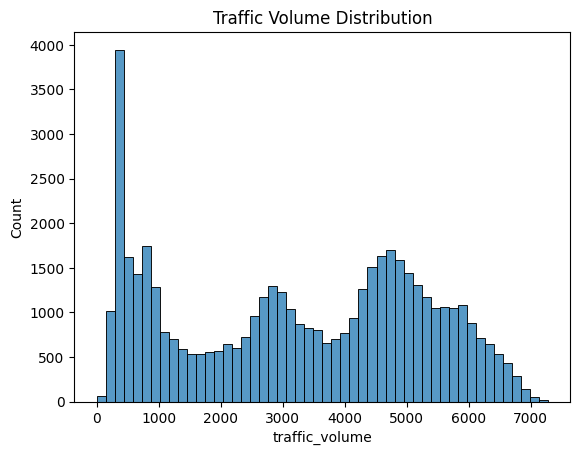

In [24]:
sns.histplot(df["traffic_volume"],bins = 50)
plt.title("Traffic Volume Distribution")
plt.show()

 - The traffic volume distribution is multimodal, showing multiple peaks corresponding to different traffic conditions throughout the day. Lower traffic is observed during nighttime, while higher peaks represent rush hours. This indicates that traffic volume is highly dependent on time-based factors and varies significantly across different periods, making it suitable for predictive modeling.

### 2.Temparature Impact

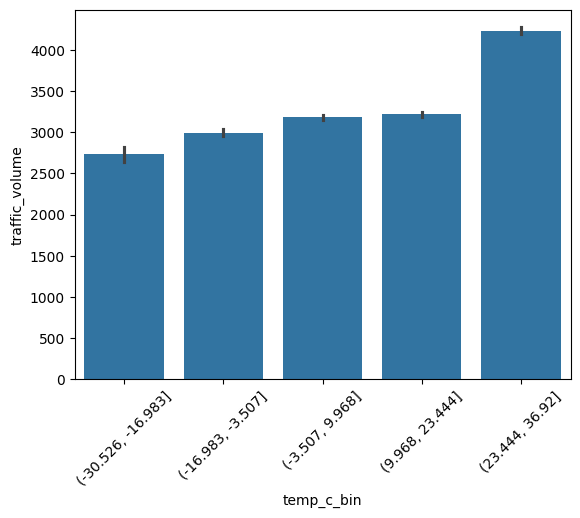

In [25]:
df['temp_c'] = df['temp'] - 273.15
df["temp_c_bin"] = pd.cut(df["temp_c"],bins = 5)
sns.barplot(x="temp_c_bin", y="traffic_volume", data=df)
plt.xticks(rotation = 45)
plt.show()

 - Traffic volume shows a positive relationship with temperature. Extremely cold conditions are associated with lower traffic levels, while warmer temperatures—especially above ~23°C—correlate with a significant increase in traffic. This suggests that weather conditions play a meaningful role in influencing travel behavior.

### 3.Rain Impact

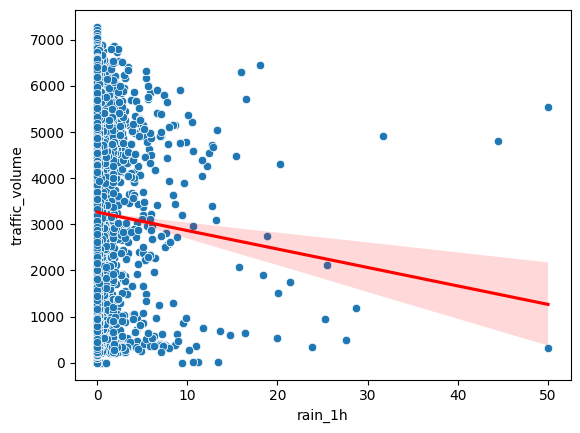

In [26]:
df["rain_1h"] = df["rain_1h"].clip(upper=50)
sns.scatterplot(data=df, x="rain_1h", y="traffic_volume")
sns.regplot(data=df, x="rain_1h", y="traffic_volume", scatter=False, line_kws={'color': 'red'})
plt.show()

- When there is no or less rain the traffic volume more,and the traffic volume gradually decreases when rain becomes heavier

### 4.Snow Impact

<Axes: xlabel='snow_1h', ylabel='traffic_volume'>

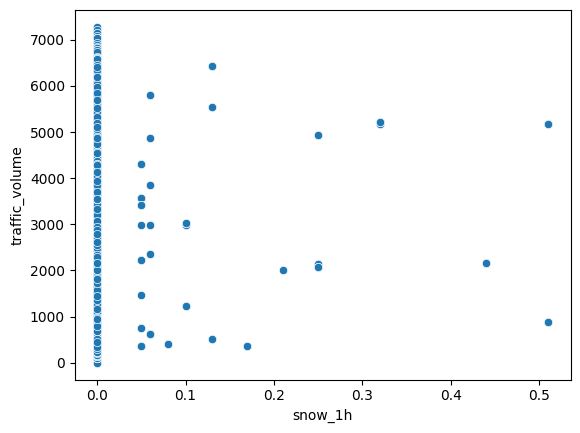

In [27]:
sns.scatterplot(data = df,x = "snow_1h",y = "traffic_volume")

- when there is less snowfall the traffic is high,and when there is heavy snowfall the traffic volume becomes low, because it is impossible to drive the vehicles in the snow

### 5.Correlation Heatmap

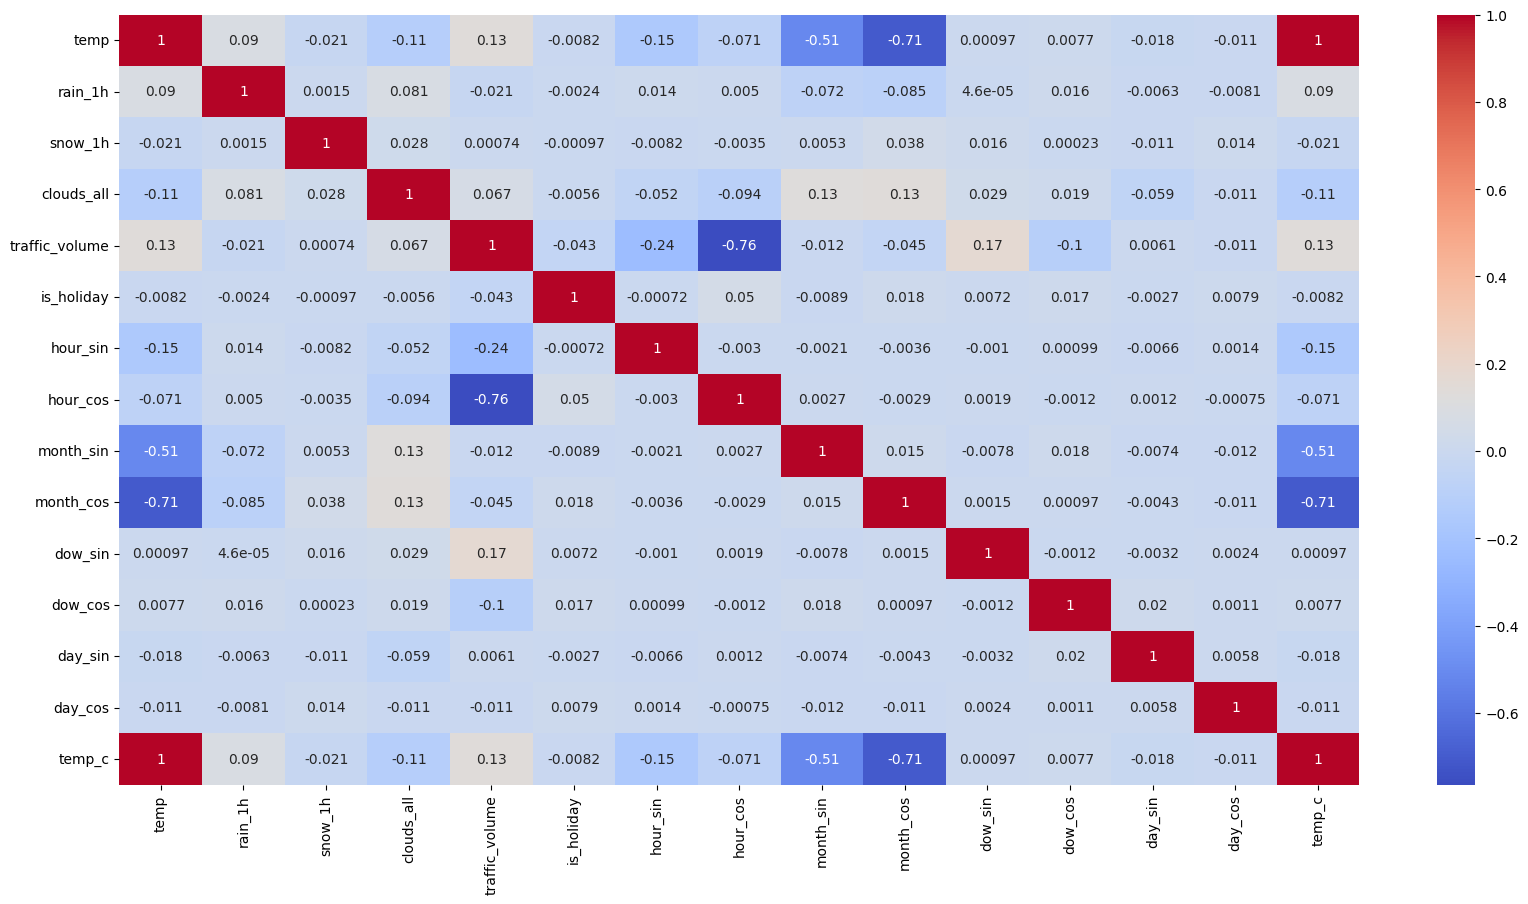

In [28]:
plt.figure(figsize = (20,10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

 - The heatmap highlights that traffic volume is largely independent of weather variables, showing almost no correlation with rain, snow, or clouds, while its strongest—though still moderate—positive correlation ($0.35$) is with the hour of the day. This confirms that time-based cycles (like rush hour) are more influential than environmental factors. Additionally, there is a perfect correlation ($1.0$) between temp and temp_c, which is expected as they are the same metric in different units, while year and month also show a perfect correlation in this specific slice of data, suggesting they might be redundant or linked to a specific chronological index. Overall, the blue-dominant map indicates a "weakly coupled" system where most features do not linearly influence one another, reinforcing that predicting traffic requires looking at temporal patterns rather than just the weather.

In [29]:
df.dtypes

temp               float64
rain_1h            float64
snow_1h            float64
clouds_all           int64
weather_main        object
traffic_volume       int64
is_holiday           int64
hour_sin           float64
hour_cos           float64
month_sin          float64
month_cos          float64
dow_sin            float64
dow_cos            float64
day_sin            float64
day_cos            float64
temp_c             float64
temp_c_bin        category
dtype: object

In [30]:
df = df.drop(columns = ["temp_c","temp_c_bin"],axis = 1)

In [31]:
X_train.head()

,temp,rain_1h,snow_1h,clouds_all,weather_main,is_holiday,hour_sin,hour_cos,month_sin,month_cos,dow_sin,dow_cos,day_sin,day_cos
11495,262.85,0.0,0.0,90,Clouds,0,-0.500000,-0.866025,0.500000,0.866025,0.974928,-0.222521,0.101168,-0.994869
17524,289.52,0.0,0.0,90,Thunderstorm,0,0.707107,0.707107,-0.866025,-0.500000,0.974928,-0.222521,-0.651372,-0.758758
25713,291.99,0.0,0.0,12,Clouds,0,-0.258819,0.965926,-0.866025,-0.500000,-0.974928,-0.222521,0.485302,-0.874347
30271,275.08,0.0,0.0,90,Drizzle,0,0.866025,-0.500000,0.500000,0.866025,-0.433884,-0.900969,-0.790776,-0.612106
36495,294.86,0.0,0.0,90,Drizzle,0,-0.965926,-0.258819,-0.866025,-0.500000,0.000000,1.000000,-0.897805,-0.440394


## Model Training using KNN Regression

In [32]:
# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor

pipeline_knn = Pipeline(steps = [('preprocessor',transformer),
                             ('model',KNeighborsRegressor())
                            ])

param_grid = {
    "model__n_neighbors" : [3,5,7,9],
    "model__weights" : ["uniform","distance"],
    "model__p" : [1,2]
}

grid = GridSearchCV(estimator = pipeline_knn,param_grid = param_grid,cv = 5,scoring = "r2",verbose = 1)
grid.fit(X_train,y_train)
model_knn = grid.best_estimator_

# Training Score
from sklearn.metrics import r2_score
y_train_pred_knn = model_knn.predict(X_train)
y_train_score_knn = r2_score(y_train,y_train_pred_knn)
print("Training Score of knn : ",y_train_score_knn)

# Testing Score
y_test_pred_knn = model_knn.predict(X_test)
y_test_score_knn = r2_score(y_test,y_test_pred_knn)
print("Testing Score of knn : ",y_test_score_knn)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Training Score of knn :  0.9999999999999938
Testing Score of knn :  0.9046539011725209


## Model Training using DecisionTree Regressor

In [33]:
from sklearn.tree import DecisionTreeRegressor
dt = DecisionTreeRegressor(random_state = 42)

pipeline_dt = Pipeline([
    ('preprocessor', transformer),  # from your previous code
    ('model', dt)
])

param_grid = {
    "model__max_depth" : [3,5,10,None],
    "model__min_samples_split" : [2,5,10],
    "model__min_samples_leaf" : [1,2,4],
    "model__max_features" : [None,"sqrt","log2"],
    "model__criterion" : ["squared_error","absolute_error"]
}
grid_dt = GridSearchCV(
    estimator = pipeline_dt,
    param_grid = param_grid,
    cv = 5,
    scoring = 'r2',
    verbose = 1,
    n_jobs = -1
)
grid_dt.fit(X_train,y_train)

model_dt = grid_dt.best_estimator_

# Training Score
from sklearn.metrics import r2_score
y_train_pred_dt = model_dt.predict(X_train)
y_train_score_dt = r2_score(y_train,y_train_pred_dt)
print("Training Score of DT : ",y_train_score_dt)
print()
# Testing Score
y_test_pred_dt = model_dt.predict(X_test)
y_test_score_dt = r2_score(y_test,y_test_pred_dt)
print("Testing Score of DT : ",y_test_score_dt)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Training Score of DT :  0.9804620526284965

Testing Score of DT :  0.9536462976245684


## Model Training Using LinearRegressor

In [34]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

pipeline_lr = Pipeline([
    ('preprocessor', transformer),  # handles encoding & scaling
    ('model', lr)
])

pipeline_lr.fit(X_train,y_train)

# Training Score
from sklearn.metrics import r2_score
y_train_pred_lr = pipeline_lr.predict(X_train)
y_train_score_lr = r2_score(y_train,y_train_pred_lr)
print("Training Score of LinearRegressor : ",y_train_score_lr)
print()
# Testing Score
y_test_pred_lr = pipeline_lr.predict(X_test)
y_test_score_lr = r2_score(y_test,y_test_pred_lr)
print("Testing Score of LinearRegressor : ",y_test_score_lr)

Training Score of LinearRegressor :  0.6873074582848572

Testing Score of LinearRegressor :  0.6904838758117646


In [35]:
# by using Lasso
from sklearn.linear_model import Lasso
lar = Lasso(alpha = 0.1)

pipeline_lar = Pipeline([
    ('preprocessor', transformer),  # handles encoding & scaling
    ('model', lar)
])

pipeline_lar.fit(X_train,y_train)

## Training Score
y_train_predict_lasso = pipeline_lar.predict(X_train)
y_train_score_lasso = r2_score(y_train,y_train_predict_lasso)
print("Training Score of Lasso :",y_train_score_lasso)
print()
# Testing Score
y_test_pred_lasso = pipeline_lar.predict(X_test)
y_test_score_lasso = r2_score(y_test,y_test_pred_lasso)
print("Testing Score of Lasso : ",y_test_score_lasso)

Training Score of Lasso : 0.6872729254480103

Testing Score of Lasso :  0.6904873498187502


In [36]:
## by using Ridge
from sklearn.linear_model import Ridge

rdg = Ridge(alpha=1.0)

pipeline_rdg = Pipeline([
    ('preprocessor', transformer),  # handles encoding & scaling
    ('model', rdg)
])
pipeline_rdg.fit(X_train, y_train)

## Training Score
y_train_predict_rdg = pipeline_rdg.predict(X_train)
y_train_score_rdg = r2_score(y_train,y_train_predict_rdg)
print("Training Score of ridge :",y_train_score_rdg)
# Testing Score
y_test_pred_rdg = pipeline_rdg.predict(X_test)
y_test_score_rdg = r2_score(y_test,y_test_pred_rdg)
print("Testing Score of ridge : ",y_test_score_rdg)

Training Score of ridge : 0.6873054663288499
Testing Score of ridge :  0.6904916601484454


In [37]:
## by using ElasticNet
from sklearn.linear_model import ElasticNet
esn = ElasticNet(alpha=0.1, l1_ratio=0.5)

pipeline_esn = Pipeline([
    ('preprocessor', transformer),  # handles encoding & scaling
    ('model', esn)
])
pipeline_esn.fit(X_train, y_train)

## Training Score
y_train_predict_esn = pipeline_esn.predict(X_train)
y_train_score_esn = r2_score(y_train,y_train_predict_esn)
print("Training Score of elastic :",y_train_score_esn)

# Testing Score
y_test_pred_esn = pipeline_esn.predict(X_test)
y_test_score_esn = r2_score(y_test,y_test_pred_esn)
print("Testing Score of elastic : ",y_test_score_esn)# Testing Score

Training Score of elastic : 0.685407590755821
Testing Score of elastic :  0.688522072264601


## Model Training Using RandomForestClassifier

In [38]:
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor()


pipeline_rfr = Pipeline([
    ('preprocessor', transformer),  # handles encoding & scaling
    ('model', rfr)
])
param_grid = {
    "model__n_estimators": [20, 50],       
    "model__max_depth": [5, 10],           
    "model__min_samples_leaf": [1, 2]
}
grid_rfr = GridSearchCV(estimator = pipeline_rfr,param_grid = param_grid,cv = 5,scoring = "r2",verbose = 1,n_jobs = -1)
grid_rfr.fit(X_train,y_train)

model_rfr = grid_rfr.best_estimator_

## Training Score
y_train_predict_rfr = model_rfr.predict(X_train)
y_train_score_rfr = r2_score(y_train,y_train_predict_rfr)
print("Training Score of random :",y_train_score_rfr)
# Testing Score
y_test_pred_rfr = model_rfr.predict(X_test)
y_test_score_rfr = r2_score(y_test,y_test_pred_rfr)
print("Testing Score of random : ",y_test_score_rfr)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Training Score of random : 0.9591395075064344
Testing Score of random :  0.9518195507142315


## Model Training using AdaBoost

In [39]:
from sklearn.ensemble import AdaBoostRegressor
ada = AdaBoostRegressor(n_estimators = 100,random_state = 42)

pipeline_ada = Pipeline([
    ("preprocesor" , transformer),
     ("model" , ada)
])
pipeline_ada.fit(X_train,y_train)

## Training Score
y_train_predict_ada = pipeline_ada.predict(X_train)
y_train_score_ada = r2_score(y_train,y_train_predict_ada)
print("Training Score of ada :",y_train_score_ada)
# Testing Score
y_test_pred_ada = pipeline_ada.predict(X_test)
y_test_score_ada = r2_score(y_test,y_test_pred_ada)
print("Testing Score of ada : ",y_test_score_ada)

Training Score of ada : 0.8435874625421229
Testing Score of ada :  0.8431163380671564


## Model Training Using GradientBoosting

In [40]:
from sklearn.ensemble import GradientBoostingRegressor
gbr = GradientBoostingRegressor(n_estimators = 100,max_depth = 3,random_state = 42)

pipeline_gbr = Pipeline([
    ("preprocesor" , transformer),
     ("model" , gbr)
])

pipeline_gbr.fit(X_train,y_train)

## Training Score
y_train_predict_gbr = pipeline_gbr.predict(X_train)
y_train_score_gbr = r2_score(y_train,y_train_predict_gbr)
print("Training Score of gradient :",y_train_score_gbr)
# Testing Score
y_test_pred_gbr = pipeline_gbr.predict(X_test)
y_test_score_gbr = r2_score(y_test,y_test_pred_gbr)
print("Testing Score of gradient : ",y_test_score_gbr)

Training Score of gradient : 0.9395757112701795
Testing Score of gradient :  0.9391713013399454


## Model Training Using XGBoost

In [41]:
from xgboost import XGBRegressor
xgb = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric='rmse'  
)
pipeline_xgb = Pipeline([
    ("preprocesor" , transformer),
     ("model" , xgb)
])
pipeline_xgb.fit(X_train, y_train)

## Training Score
y_train_predict_xgb = pipeline_xgb.predict(X_train)
y_train_score_xgb = r2_score(y_train,y_train_predict_xgb)
print("Training Score of XGB :",y_train_score_xgb)
# Testing Score
y_test_pred_xgb = pipeline_xgb.predict(X_test)
y_test_score_xgb = r2_score(y_test,y_test_pred_xgb)
print("Testing Score of XGB : ",y_test_score_xgb)

Training Score of XGB : 0.9393249154090881
Testing Score of XGB :  0.9393426775932312


In [48]:
from sklearn.metrics import mean_squared_error,mean_absolute_error
models = {
    "Linear Regression": LinearRegression(),
    "KNN": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Gradient Boosting": GradientBoostingRegressor()
}
results = []

for name, model in models.items():
    
    # Create pipeline
    pipeline = Pipeline([
        ("preprocessor", transformer),
        ("model", model)
    ])
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    
    # Metrics
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    # Store results
    results.append({
        "Model": name,
        "R2 Score": r2,
        "RMSE": rmse,
        "MAE": mae
    })
results_df = pd.DataFrame(results)

# Sort by best model (highest R2)
results_df = results_df.sort_values(by="R2 Score", ascending=False)

print(results_df)

               Model  R2 Score         RMSE         MAE
3      Random Forest  0.968270   356.457156  208.911282
4  Gradient Boosting  0.939171   493.545871  311.732129
2      Decision Tree  0.938592   495.891609  258.077194
1                KNN  0.891590   658.883240  455.183648
0  Linear Regression  0.690484  1113.306897  855.949339


## Pickle Creation

In [42]:
import pickle

In [43]:
with open("traffic_volume_prediction.pkl","wb") as f:
    pickle.dump(model_rfr,f)

In [44]:
import sys
print(sys.version)

3.12.3 | packaged by conda-forge | (main, Apr 15 2024, 18:20:11) [MSC v.1938 64 bit (AMD64)]


In [45]:
import sklearn
print(sklearn.__version__)

1.8.0
